In [1]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool, cv, CatBoostRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold
import re
import sys
import csv
from download_datasets import create_comprehensive_xss_dataset
import urllib

import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

📁 Создаю датасет в папке: ./datasets_test

1. Создание основного датасета...
   ✅ Основной CSV: ./datasets_test\xss_dataset.csv (13226 записей)
   ✅ XSS payloads: ./datasets_test\xss_payloads_only.csv (6613 записей)
   ✅ Normal HTML: ./datasets_test\normal_html_only.csv (6613 записей)
   ✅ Статистика: ./datasets_test\dataset_stats.json


In [2]:
class XSSLearnDetector:
    """Класс для детектирования XSS с мониторингом"""

    def __init__(self, model_path=None):
        if model_path:
            self.model, self.metadata = self.load_model()
        else:
            self.model = None
            self.metadata = None

        # Статистика использования
        self.stats = {
            'total_predictions': 0,
            'xss_detected': 0,
            'false_positives': 0,
            'false_negatives': 0
        }

    def train(self, csv_file):
        """Обучение модели"""
        self.model, _ = full_training_pipeline(csv_file)

    def predict(self, code, threshold=0.5):
        """Предсказание с порогом"""
        if not self.model:
            raise ValueError("Модель не обучена!")

        self.stats['total_predictions'] += 1

        result = self.predict_xss(self.model, code, self.metadata)

        # Применяем порог
        final_prediction = result['probability'] >= threshold

        # Обновляем статистику
        if final_prediction:
            self.stats['xss_detected'] += 1

        return {
            'prediction': final_prediction,
            'probability': result['probability'],
            'details': result
        }

    def save_model(self, model, feature_names, cat_features, scaler=None):
        """Сохраняет модель и метаданные"""

        model_filename = "./model/catboost_xss_model.cbm"
        metadata_filename = "./model/model_metadata.pkl"

        # Сохраняем модель
        model.save_model(model_filename)

        # Сохраняем метаданные
        metadata = {
            'feature_names': list(feature_names),
            'cat_features': cat_features,
            'model_type': 'CatBoost',
            'version': '1.0'
        }

        joblib.dump(metadata, metadata_filename)

        if scaler:
            joblib.dump(scaler, 'scaler.pkl')

        print("💾 Модель сохранена:")
        print(f"  - {model_filename} (модель)")
        print(f"  - {metadata_filename} (метаданные)")

        return model_filename, metadata_filename

    def load_model(self):
        """Загружает модель и метаданные"""
        model = CatBoostClassifier()
        model.load_model('catboost_xss_model.cbm')
        metadata = joblib.load('model_metadata.pkl')

        print("📤 Модель загружена")
        return model, metadata

    def predict_xss(self, model, text, metadata):
        """Предсказывает XSS для нового кода"""

        # Извлекаем признаки
        features = extract_features(text)
        features_df = pd.DataFrame([features])

        # Убеждаемся, что порядок признаков правильный
        features_df = features_df[metadata['feature_names']]

        # Преобразуем категориальные признаки
        for col in metadata['cat_features']:
            if col in features_df.columns:
                features_df[col] = features_df[col].astype('category')

        # Предсказание
        prediction = model.predict(features_df)[0]
        probability = model.predict_proba(features_df)[0][1]

        # Интерпретация
        result = {
            'text': text[:100] + '...' if len(text) > 100 else text,
            'is_xss': bool(prediction),
            'probability': float(probability),
            'risk_level': 'HIGH' if probability > 0.7 else 'MEDIUM' if probability > 0.3 else 'LOW'
        }

        # Детальный анализ
        if probability > 0.5:
            # Анализируем, какие признаки вызвали срабатывание
            feature_importance = model.get_feature_importance(
                data=Pool(features_df, cat_features=metadata['cat_features'], text_features=['text']),
                type='PredictionValuesChange'
            )

            top_features_idx = np.argsort(feature_importance)[-3:][::-1]
            top_features = []
            for idx in top_features_idx:
                if feature_importance[idx] > 0:
                    top_features.append(
                        f"{metadata['feature_names'][idx]}: {features[metadata['feature_names'][idx]]}"
                    )

            result['triggered_features'] = top_features

        return result

    def batch_predict(self, model, texts, metadata):
        """Пакетное предсказание"""
        results = []
        for text in texts:
            results.append(self.predict_xss(model, text, metadata))
        return pd.DataFrame(results)

    def evaluate_on_dataset(self, test_csv, threshold=0.5):
        """Оценка на тестовом датасете"""
        test_df = pd.read_csv(test_csv)

        predictions = []
        probabilities = []

        for text in test_df['text']:
            result = self.predict(text, threshold)
            predictions.append(result['prediction'])
            probabilities.append(result['probability'])

        y_true = test_df['label'].values
        y_pred = np.array(predictions)

        print("\n📊 Оценка на тестовом датасете:")
        print(classification_report(y_true, y_pred))
        print(f"AUC: {roc_auc_score(y_true, probabilities):.4f}")

        # Обновляем статистику ошибок
        cm = confusion_matrix(y_true, y_pred)
        self.stats['false_positives'] += cm[0, 1]
        self.stats['false_negatives'] += cm[1, 0]

        return classification_report(y_true, y_pred, output_dict=True)

    def get_stats(self):
        """Получить статистику"""
        return self.stats.copy()


In [3]:
def extract_features1(text):
    """Извлекает 30+ признаков из HTML/JS кода"""
    features = {}

    features['text'] = text

    # Базовые признаки
    features['length'] = len(text)
    features['word_count'] = len(re.findall(r'\b\w+\b', text))

    # Бинарные признаки (категориальные для CatBoost)
    dangerous_patterns = {
        'html_has_script': r's.*c.*r.*i.*p.*t',
        'js_has_on_event': r'o.*n\w+\s*=',
        'js_has_alert': r'a.*l.*e.*r.*t',
        'js_has_prompt': r'p.*r.*o.*m.*p.*t',
        'js_has_confirm': r'c.*o.*n.*f.*i.*r.*m.*',
        'js_has_console': r'c.*o.*n.*s.*o.*l.*e',
        'has_javascript': r'j.*a.*v.*a.*s.*c.*r.*i.*p.*t.*',
        'has_vbscript': r'v.*b.*s.*c.*r.*i.*p.*t',
        # 'has_data_scheme': r'data:',
        'js_has_document': r'd.*o.*c.*u.*m.*e.*n.*t',
        'js_has_window': r'w.*i.*n.*d.*o.*w',
        'js_has_inner_html': r'i.*n.*n.*e.*r.*H.*T.*M.*L',
        'js_has_outer_html': r'o.*u.*t.*e.*r.*H.*T.*M.*L',
        'html_has_iframe': r'i.*f.*r.*a.*m.*e',
        'html_has_svg': r's.*v.*g',
        # 'has_embed': r'e.*m.*b.*e.*d',
        # 'has_applet': r'a.*p.*p.*l.*e.*t',
        'js_has_dangerous': r'f.*u.*n.*c.*t.*i.*o.*n|j.*o.*i.*n|c.*o.*n.*s.*t.*r.*u.*c.*t.*o.*r|a.*r.*r.*a.*y|o.*b.*j.*e.*c.*t|e.*v.*a.*l|f.*e.*t.*c.*h|x.*m.*l'
    }

    for name, pattern in dangerous_patterns.items():
        features[name] = 1 if re.search(pattern, text, re.IGNORECASE) else 0

    # Количественные признаки
    # features['angle_bracket_count'] = text.count('<') + text.count('>')
    # features['parenthesis_count'] = text.count('(') + text.count(')')
    features['quote_count'] = text.count('"') + text.count("'")
    # features['semicolon_count'] = text.count(';')
    features['equals_count'] = text.count('=')
    features['sum_count'] = text.count('+')

    # Признаки кодирования
    features['has_url_encoding'] = 1 if '%' in text else 0
    features['has_html_entities'] = 1 if re.search(
        r'&#?[xX]?[0-9a-fA-F]+;', text) else 0
    features['has_hex_encoding'] = len(re.findall(r'\\x[0-9a-fA-F]{2}', text))
    features['has_unicode'] = len(re.findall(r'\\u[0-9a-fA-F]{4}', text))

    # Статистические признаки
    features['special_char_ratio'] = len(re.findall(
        r'[<>\(\)\'\"=;:]', text)) / max(len(text), 1)
    # features['angle_bracket_ratio'] = features['angle_bracket_count'] / \
    #     max(len(text), 1)

    # Структурные признаки
    features['tag_count'] = len(re.findall(r'</?\w+', text))
    features['attribute_count'] = len(re.findall(r'\w+\s*=', text))
    features['comment_count'] = text.count('<!--')

    # Энтропия (мера случайности)
    if text:
        entropy = 0
        for char in set(text):
            p_x = text.count(char) / len(text)
            if p_x > 0:
                entropy += -p_x * np.log2(p_x)
        features['entropy'] = entropy
    else:
        features['entropy'] = 0

    # Контекстные признаки
    features['is_inside_quotes'] = 1 if (
        text.count('"') > 2 or text.count("'") > 2) else 0
    features['has_nested_tags'] = 1 if re.search(r'<[^>]*<', text) else 0

    return features


def extract_features2(text):
    """
    Извлекает 25 признаков безопасности из строки (URL/HTML/JS)
    на основе спецификации.
    
    Args:
        text: Входная строка (может содержать URL, HTML, JS код)
    
    Returns:
        Словарь с признаками безопасности
    """
    features = {
        'text': text
    }
    
    # 1. url_length - длина URL
    features['url_length'] = len(text)
    
    # 2. url_special_characters - специальные символы
    special_chars = r'[!@#$%^&*()_+\-=\[\]{};:"\\|,.<>\/?~`]'
    features['url_special_characters'] = len(re.findall(special_chars, text))
    
    # 3. url_tag_script - наличие <script> в URL
    features['url_tag_script'] = 1 if re.search(r'<script[^>]*>', text, re.IGNORECASE) else 0
    
    # 4. url_cookie - упоминания cookie в URL
    cookie_patterns = [
        r'cookie', r'session', r'token', r'auth',
        r'csrf', r'jwt', r'bearer'
    ]
    has_cookie = any(re.search(pattern, text, re.IGNORECASE) for pattern in cookie_patterns)
    features['url_cookie'] = 1 if has_cookie else 0
    
    # 5. url_number_keywords_param - ключевые слова в параметрах
    keywords = [
        'signup', 'login', 'register', 'auth', 'authenticate',
        'query', 'search', 'filter', 'sort', 'order',
        'user', 'admin', 'password', 'secret', 'key',
        'token', 'id', 'email', 'phone', 'name'
    ]
    
    # Пытаемся разобрать URL
    keyword_count = 0
    try:
        parsed = urllib.parse.urlparse(text)
        query_params = urllib.parse.parse_qs(parsed.query)
        
        # Проверяем ключевые слова в параметрах
        for param_name in query_params.keys():
            param_lower = param_name.lower()
            for keyword in keywords:
                if keyword in param_lower:
                    keyword_count += 1
                    break
        
        # Проверяем ключевые слова в значениях параметров
        for param_values in query_params.values():
            for value in param_values:
                value_lower = str(value).lower()
                for keyword in keywords:
                    if keyword in value_lower:
                        keyword_count += 1
                        break
    except:
        # Если это не URL, проверяем всю строку
        text_lower = text.lower()
        for keyword in keywords:
            if keyword in text_lower:
                keyword_count += 1
    
    features['url_number_keywords_param'] = min(keyword_count, 10)  # Ограничиваем
    
    # 6. url_number_domain - количество доменов в URL
    domain_pattern = r'(?:https?://)?([a-zA-Z0-9.-]+\.[a-zA-Z]{2,})'
    domains = re.findall(domain_pattern, text)
    features['url_number_domain'] = len(set(domains))  # Уникальные домены
    
    # 7. html_tag_script - наличие <script> в HTML
    features['html_tag_script'] = features['url_tag_script']  # Используем тот же признак
    
    # 8. html_tag_meta - наличие <meta>
    features['html_tag_meta'] = 1 if re.search(r'<meta[^>]*>', text, re.IGNORECASE) else 0
    
    # 9. html_tag_link - наличие <link>
    features['html_tag_link'] = 1 if re.search(r'<link[^>]*>', text, re.IGNORECASE) else 0
    
    # 10. html_tag_div - наличие <div>
    features['html_tag_div'] = 1 if re.search(r'<div[^>]*>', text, re.IGNORECASE) else 0
    
    # 11. html_tag_style - наличие <style>
    features['html_tag_style'] = 1 if re.search(r'<style[^>]*>', text, re.IGNORECASE) else 0
    
    # 12. html_attr_background - наличие атрибута background
    background_patterns = [
        r'background\s*=',
        r'style\s*=[^>]*background',
        r'bgcolor\s*='
    ]
    has_background = any(re.search(pattern, text, re.IGNORECASE) for pattern in background_patterns)
    features['html_attr_background'] = 1 if has_background else 0
    
    # 13. html_attr_href - наличие атрибута href
    features['html_attr_href'] = 1 if re.search(r'href\s*=', text, re.IGNORECASE) else 0
    
    # 14. html_attr_src - наличие атрибута src
    features['html_attr_src'] = 1 if re.search(r'src\s*=', text, re.IGNORECASE) else 0
    
    # 15. html_event_onmouseout - наличие события onmouseout
    features['html_event_onmouseout'] = 1 if re.search(r'onmouseout\s*=', text, re.IGNORECASE) else 0
    
    # 16. js_file - ссылки на JS файлы
    js_file_patterns = [
        r'\.js\b',
        r'<script[^>]*src\s*=\s*["\'][^"\']+\.js',
        r'import.*\.js',
        r'require.*\.js'
    ]
    has_js_file = any(re.search(pattern, text, re.IGNORECASE) for pattern in js_file_patterns)
    features['js_file'] = 1 if has_js_file else 0
    
    # 17. js_dom_location - использование location в JS
    features['js_dom_location'] = 1 if re.search(r'\blocation\b', text, re.IGNORECASE) else 0
    
    # 18. js_dom_document - использование document в JS
    features['js_dom_document'] = 1 if re.search(r'\bdocument\b', text, re.IGNORECASE) else 0
    
    # 19. js_method_getElementsByTagName - использование getElementsByTagName
    features['js_method_getElementsByTagName'] = 1 if re.search(r'getElementsByTagName', text, re.IGNORECASE) else 0
    
    # 20. js_method_getElementById - использование getElementById
    features['js_method_getElementById'] = 1 if re.search(r'getElementById', text, re.IGNORECASE) else 0
    
    # 21. js_method_alert - использование alert
    features['js_method_alert'] = 1 if re.search(r'\balert\s*\(', text, re.IGNORECASE) else 0
    
    # 22. js_min_length - минимальная длина JS строк (упрощенно)
    # Ищем строки в кавычках
    string_pattern = r'["\'`]([^"\']{1,50})["\'`]'
    strings = re.findall(string_pattern, text)
    
    if strings:
        min_length = min(len(s) for s in strings)
    else:
        min_length = 0
    
    features['js_min_length'] = min_length
    
    # 23. js_min_function_calls - минимальное количество вызовов функций
    # Считаем количество вызовов функций
    function_call_pattern = r'\b\w+\s*\('
    function_calls = re.findall(function_call_pattern, text)
    
    # Исключаем ключевые слова, которые не являются функциями
    non_function_keywords = {'if', 'else', 'for', 'while', 'switch', 'function'}
    valid_function_calls = [fc for fc in function_calls 
                           if not any(kw in fc.lower() for kw in non_function_keywords)]
    
    features['js_min_function_calls'] = len(valid_function_calls)
    
    # 24. js_string_max_length - максимальная длина JS строк
    if strings:
        max_length = max(len(s) for s in strings)
    else:
        max_length = 0
    
    features['js_string_max_length'] = max_length
    
    # 25. html_length - длина HTML контента
    # Для чистоты, если это выглядит как HTML
    features['html_length'] = len(text) if ('<' in text and '>' in text) else 0
    
    return features


def extract_features(text):
    """Извлекает 80 признаков XSS из HTML/JS кода на основе исследования XSShield"""
    features = {
        'text': text
    }
    
    # Все 80 признаков из таблицы A.6 исследования XSShield
    # Формат: название_признака: регулярное_выражение_для_поиска
    xss_patterns = {
        # HTML теги (1-13)
        'html_tag_main': r'<main',
        'html_tag_section': r'<section',
        'html_tag_script': r'<script',
        'html_tag_iframe': r'<iframe',
        'html_tag_meta': r'<meta',
        'html_tag_link': r'<link',
        'html_tag_svg': r'<svg',
        'html_tag_form': r'<form',
        'html_tag_div': r'<div',
        'html_tag_style': r'<style',
        'html_tag_img': r'<img',
        'html_tag_input': r'<input',
        'html_tag_textarea': r'<textarea',
        
        # HTML атрибуты (14-21)
        'html_attr_selected': r'selected\s*=',
        'html_attr_target': r'target\s*=',
        'html_attr_class': r'class\s*=',
        'html_attr_action': r'action\s*=',
        'html_attr_background': r'background\s*=',
        'html_attr_href': r'href\s*=',
        'html_attr_src': r'src\s*=',
        'html_attr_http_equiv': r'http-equiv\s*=',
        
        # HTML события (22-28)
        'html_event_enhance': r'enhance\s*=',
        'html_event_onclick': r'onclick\s*=',
        'html_event_onfocus': r'onfocus\s*=',
        'html_event_onload': r'onload\s*=',
        'html_event_omouseover': r'omouseover\s*=',
        'html_event_onmouseover': r'onmouseover\s*=',
        'html_event_onsubmit': r'onsubmit\s*=',
        
        # HTML длина (29)
        'html_length': lambda t: len(t),
        
        # JS DOM объекты (30-38)
        'js_dom_document': r'document\.',
        'js_dom_window': r'window\.',
        'js_dom_navigator': r'navigator\.',
        'js_dom_location': r'location\.',
        'js_dom_localStorage': r'localStorage\.',
        'js_dom_sessionStorage': r'sessionStorage\.',
        'js_dom_history': r'history\.',
        'js_dom_console': r'console\.',
        'js_dom_alert': r'alert\(',
        
        # JS свойства (39-46)
        'js_prop_cookie': r'\.cookie',
        'js_prop_referrer': r'\.referrer',
        'js_prop_innerHTML': r'\.innerHTML',
        'js_prop_textContent': r'\.textContent',
        'js_prop_value': r'\.value',
        'js_prop_href': r'\.href',
        'js_prop_src': r'\.src',
        'js_prop_classList': r'\.classList',
        
        # JS методы (47-52)
        'js_method_getAttribute': r'\.getAttribute\(',
        'js_method_setAttribute': r'\.setAttribute\(',
        'js_method_write': r'\.write\(',
        'js_method_getElementsByTagName': r'\.getElementsByTagName\(',
        'js_method_getElementById': r'\.getElementById\(',
        'js_method_fromCharCode': r'\.fromCharCode\(',
        
        # JS длина строк (53-54)
        'js_min_length': lambda t: min([len(s) for s in re.findall(r'["\']([^"\']*)["\']', t)] or [0]),
        'js_max_length': lambda t: max([len(s) for s in re.findall(r'["\']([^"\']*)["\']', t)] or [0]),
        
        # JS функции (55-56)
        'js_define_function': r'function\s+\w+\s*\(|\w+\s*=\s*function\s*\(',
        'js_function_calls': len(re.findall(r'\w+\s*\(', text)),
        
        # JS файлы и протоколы (57-58)
        'js_file': r'\.js["\']',
        'js_pseudo_protocol': r'javascript:|data:|vbscript:',
        
        # URL признаки (59-68) - теги в URL
        'url_length': lambda t: len(t),
        'url_tag_script': r'script',
        'url_tag_iframe': r'iframe',
        'url_tag_link': r'link',
        'url_tag_frame': r'frame',
        'url_tag_form': r'form',
        'url_tag_style': r'style',
        'url_tag_video': r'video',
        'url_tag_img': r'img',
        'url_tag_main': r'main',
        
        # URL признаки (69-70) - дополнительные теги
        'url_tag_section': r'section',
        'url_tag_article': r'article',
        
        # URL атрибуты (71-73)
        'url_attr_action': r'action',
        'url_attr_data': r'data',
        'url_attr_src': r'src',
        
        # URL события (74-76)
        'url_event_onerror': r'onerror',
        'url_event_onload': r'onload',
        'url_event_onmouseover': r'onmouseover',
        
        # URL параметры и ключевые слова (77-78)
        'url_keywords_param': r'[\?&]\w+=',
        'url_keywords_evil': r'(alert|prompt|confirm|eval|script|iframe)',
        
        # URL дополнительные признаки (79-80)
        'url_cookie': r'cookie',
        'url_number_domain': len(re.findall(r'https?://([\w\.]+)', text))
    }
    
    # Извлекаем все признаки
    for feature_name, pattern in xss_patterns.items():
        if callable(pattern):
            # Если это функция (лямбда), вызываем её
            features[feature_name] = pattern(text)
        elif feature_name in ['js_function_calls', 'url_number_domain']:
            # Эти уже посчитаны в словаре
            features[feature_name] = pattern
        else:
            # Регулярное выражение - ищем совпадения
            if isinstance(pattern, int):
                features[feature_name] = pattern
            else:
                matches = re.findall(pattern, text, re.IGNORECASE)
                if feature_name in ['js_min_length', 'js_max_length']:
                    features[feature_name] = matches if matches else 0
                else:
                    features[feature_name] = len(matches)
        
    return features

In [4]:
def train_final_model(X, y, cat_features, params):
    """Обучает финальную модель на всех данных"""

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    train_pool = Pool(X_train, y_train, cat_features=cat_features, text_features=['text'])
    val_pool = Pool(X_val, y_val, cat_features=cat_features, text_features=['text'])

    print("🚀 Обучение финальной модели...")

    model = CatBoostClassifier(**params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        verbose=100,
        plot=True
    )

    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]

    print("\n📈 Метрики на валидационной выборке:")
    print(classification_report(y_val, y_pred))
    print(f"AUC: {roc_auc_score(y_val, y_pred_proba):.4f}")

    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Матрица ошибок')
    plt.ylabel('Истинные значения')
    plt.xlabel('Предсказанные значения')
    plt.savefig('./confusion_matrix.png')
    plt.show()

    return model


In [5]:

def load_and_prepare_data(csv_file, with_label: bool = True):
    """Загружает CSV и преобразует в признаки"""
    print("📥 Загрузка данных...")
    df = pd.read_csv(csv_file)

    print("🔧 Извлечение признаков...")
    features_list = []
    for i, text in enumerate(df['text']):
        if i % 500 == 0:
            print(f"  Обработано {i}/{len(df)}...")
        features_list.append(extract_features(text))

    X = pd.DataFrame(features_list)
    y = df['label'].values if with_label else None

    print(
        f"✅ Данные подготовлены: {X.shape[0]} примеров, {X.shape[1]} признаков")
    if with_label:
        print(
            f"📊 Распределение классов: {y.sum()} XSS, {len(y)-y.sum()} нормальных")

    return X, y


def get_categorical_features(X: pd.DataFrame):
    """Определяет, какие признаки категориальные"""
    categorical = []

    for col in X.columns:
        if X[col].nunique() <= 8 and set(X[col].unique()).issubset({0, 1}):
            categorical.append(col)

    print(f"🎯 Категориальные признаки ({len(categorical)}): {categorical}")
    return categorical


def train_with_cross_validation(X, y, cat_features):
    """Обучает CatBoost с кросс-валидацией"""

    pool = Pool(data=X, label=y, cat_features=cat_features, text_features=['text'])

    params = {
        'iterations': 10000,
        'depth': 6,
        'learning_rate': 0.05,
        'loss_function': 'Logloss',
        'verbose': 100,
        'random_seed': 42,
        'task_type': 'GPU',
        'eval_metric': 'AUC',
        'early_stopping_rounds': 50,
        'use_best_model': True,
        'bootstrap_type': 'Bernoulli',
        'subsample': 0.8,
        'l2_leaf_reg': 3,
        'metric_period': 50,
        'devices': '0:1'
    }

    print("🔄 Начинаю кросс-валидацию...")

    # 5-фолдная кросс-валидация
    cv_data = cv(
        pool=pool,
        params=params,
        fold_count=5,
        shuffle=True,
        partition_random_seed=42,
        stratified=True,
        verbose=False,
        plot=True
    )

    print("\n📊 Результаты кросс-валидации:")
    print(f"Лучшая AUC на валидации: {cv_data['test-AUC-mean'].max():.4f}")
    print(
        f"Среднее AUC: {cv_data['test-AUC-mean'].mean():.4f} ± {cv_data['test-AUC-std'].mean():.4f}")

    return cv_data, params


def analyze_feature_importance(model, X):
    """Анализирует важность признаков"""

    # Получаем важность признаков
    feature_importance = model.get_feature_importance()
    feature_names = X.columns

    # Создаем DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)

    # Визуализация
    plt.figure(figsize=(12, 30))
    plt.barh(range(len(importance_df)), importance_df['importance'])
    plt.yticks(range(len(importance_df)), importance_df['feature'])
    plt.xlabel('Важность')
    plt.title('Важность признаков (CatBoost)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('./features.png')
    plt.show()

    return importance_df

In [ ]:
class XSSTestDetector:
    """Класс для детектирования XSS с загруженной моделью"""

    def __init__(self, model_path='catboost_xss_model.cbm',
                 metadata_path='model_metadata.pkl'):
        self.model_path = model_path
        self.metadata_path = metadata_path
        self.model = None
        self.metadata = None
        self.load_model()

    def load_model(self):
        """Загружает модель из файлов"""
        try:
            self.model = CatBoostClassifier()
            self.model.load_model(self.model_path)

            self.metadata = joblib.load(self.metadata_path)

            print(f"✅ Модель успешно загружена")
            print(f"   Признаков: {len(self.metadata['feature_names'])}")
            print(
                f"   Категориальных: {len(self.metadata.get('cat_features', []))}")

        except Exception as e:
            print(f"❌ Ошибка загрузки модели: {e}")
            raise

    def prepare_features(self, features_dict):
        """Подготовка признаков для модели"""
        features_df = pd.DataFrame([features_dict])

        expected_features = self.metadata['feature_names']
        for feature in expected_features:
            if feature not in features_df.columns:
                features_df[feature] = 0  # Заполняем недостающие нулями

        features_df = features_df[expected_features]

        cat_features = self.metadata.get('cat_features', [])
        for col in cat_features:
            if col in features_df.columns:
                features_df[col] = features_df[col].astype('category')

        return features_df

    def predict(self, code, threshold=0.5):
        """
        Предсказывает, является ли код XSS

        Args:
            code (str): HTML/JS код для проверки
            threshold (float): Порог вероятности (0.5 по умолчанию)

        Returns:
            dict: Результат предсказания
        """
        if self.model is None:
            raise ValueError("Модель не загружена!")

        features = extract_features(code)

        features_df = self.prepare_features(features)

        prediction = self.model.predict(features_df)[0]
        probability = self.model.predict_proba(features_df)[0][1]

        is_xss = probability >= threshold

        return {
            'is_xss': bool(is_xss),
            'probability': float(probability),
            'prediction': prediction,
            'threshold': threshold,
            'code_sample': code[:100] + '...' if len(code) > 100 else code,
            'risk_level': self._get_risk_level(probability),
            'features': self._get_top_features(features_df, features)
        }

    def predict_batch(self, codes, threshold=0.5):
        """Пакетное предсказание"""
        results = []
        for code in codes:
            results.append(self.predict(code, threshold, return_details=True))
        return pd.DataFrame(results)

    def _get_risk_level(self, probability):
        """Определяет уровень риска"""
        if probability >= 0.8:
            return "CRITICAL"
        elif probability >= 0.6:
            return "HIGH"
        elif probability >= 0.4:
            return "MEDIUM"
        elif probability >= 0.2:
            return "LOW"
        else:
            return "SAFE"

    def _get_top_features(self, features_df, original_features):
        """Возвращает топ признаков, повлиявших на решение"""
        try:
            # Получаем важность признаков для этого конкретного предсказания
            shap_values = self.model.get_feature_importance(
                data=features_df,
                type='PredictionValuesChange'
            )

            # Сортируем по важности
            feature_names = self.metadata['feature_names']
            important = []

            for idx in np.argsort(shap_values)[-5:][::-1]:
                if shap_values[idx] > 0:
                    feature_name = feature_names[idx]
                    feature_value = original_features.get(feature_name, 0)
                    important.append(f"{feature_name}={feature_value}")

            return important
        except:
            return []

    def get_model_info(self):
        """Информация о модели"""
        if self.model is None:
            return "Модель не загружена"

        info = {
            'model_type': 'CatBoost',
            'feature_count': len(self.metadata['feature_names']),
            'cat_features': len(self.metadata.get('cat_features', [])),
            'tree_count': self.model.tree_count_ if hasattr(self.model, 'tree_count_') else 'N/A',
            'classes': list(self.model.classes_) if hasattr(self.model, 'classes_') else [0, 1]
        }

        return info

In [7]:
train_filename = './XSS_dataset.csv'
test_filename = './datasets_test/xss_dataset.csv'

In [8]:
print("\n" + "="*60)
print("НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ DETECT XSS")
print("="*60 + "\n")

print("=" * 60)
print("🚀 ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА ОБУЧЕНИЯ CATBOOST")
print("=" * 60)

learn_detector = XSSLearnDetector()

X, y = load_and_prepare_data(train_filename)

cat_features = get_categorical_features(X)

feature_weights = []

for f in cat_features:
    if 'js' in f:
        feature_weights.append(1.0)
    if 'html' in f:
        feature_weights.append(0.7)
    else:
        feature_weights.append(0.5)


cv_results, best_params = train_with_cross_validation(X, y, cat_features)


НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ DETECT XSS

🚀 ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА ОБУЧЕНИЯ CATBOOST
📥 Загрузка данных...
🔧 Извлечение признаков...
  Обработано 0/13686...
  Обработано 500/13686...
  Обработано 1000/13686...
  Обработано 1500/13686...
  Обработано 2000/13686...
  Обработано 2500/13686...
  Обработано 3000/13686...
  Обработано 3500/13686...
  Обработано 4000/13686...
  Обработано 4500/13686...
  Обработано 5000/13686...
  Обработано 5500/13686...
  Обработано 6000/13686...
  Обработано 6500/13686...
  Обработано 7000/13686...
  Обработано 7500/13686...
  Обработано 8000/13686...
  Обработано 8500/13686...
  Обработано 9000/13686...
  Обработано 9500/13686...
  Обработано 10000/13686...
  Обработано 10500/13686...
  Обработано 11000/13686...
  Обработано 11500/13686...
  Обработано 12000/13686...
  Обработано 12500/13686...
  Обработано 13000/13686...
  Обработано 13500/13686...
✅ Данные подготовлены: 13686 примеров, 81 признаков
📊 Распределение классов: 7373 XSS, 6313 нормальных
🎯 Категор

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]
bestTest = 0.9999637902
bestIteration = 160
Training on fold [1/5]
bestTest = 0.9999565184
bestIteration = 66
Training on fold [2/5]
bestTest = 0.9999855161
bestIteration = 148
Training on fold [3/5]
bestTest = 0.9999594092
bestIteration = 42
Training on fold [4/5]
bestTest = 0.9999040365
bestIteration = 35

📊 Результаты кросс-валидации:
Лучшая AUC на валидации: 0.9999
Среднее AUC: 0.9989 ± 0.0004


🚀 Обучение финальной модели...


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.9964185	best: 0.9964185 (0)	total: 59ms	remaining: 9m 49s
bestTest = 0.9999543726
bestIteration = 49
Shrink model to first 50 iterations.

📈 Метрики на валидационной выборке:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1263
           1       1.00      0.99      1.00      1475

    accuracy                           1.00      2738
   macro avg       1.00      1.00      1.00      2738
weighted avg       1.00      1.00      1.00      2738

AUC: 1.0000


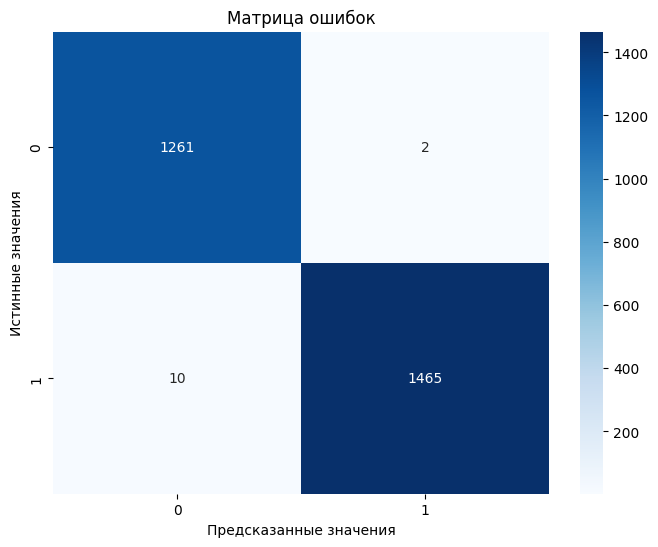

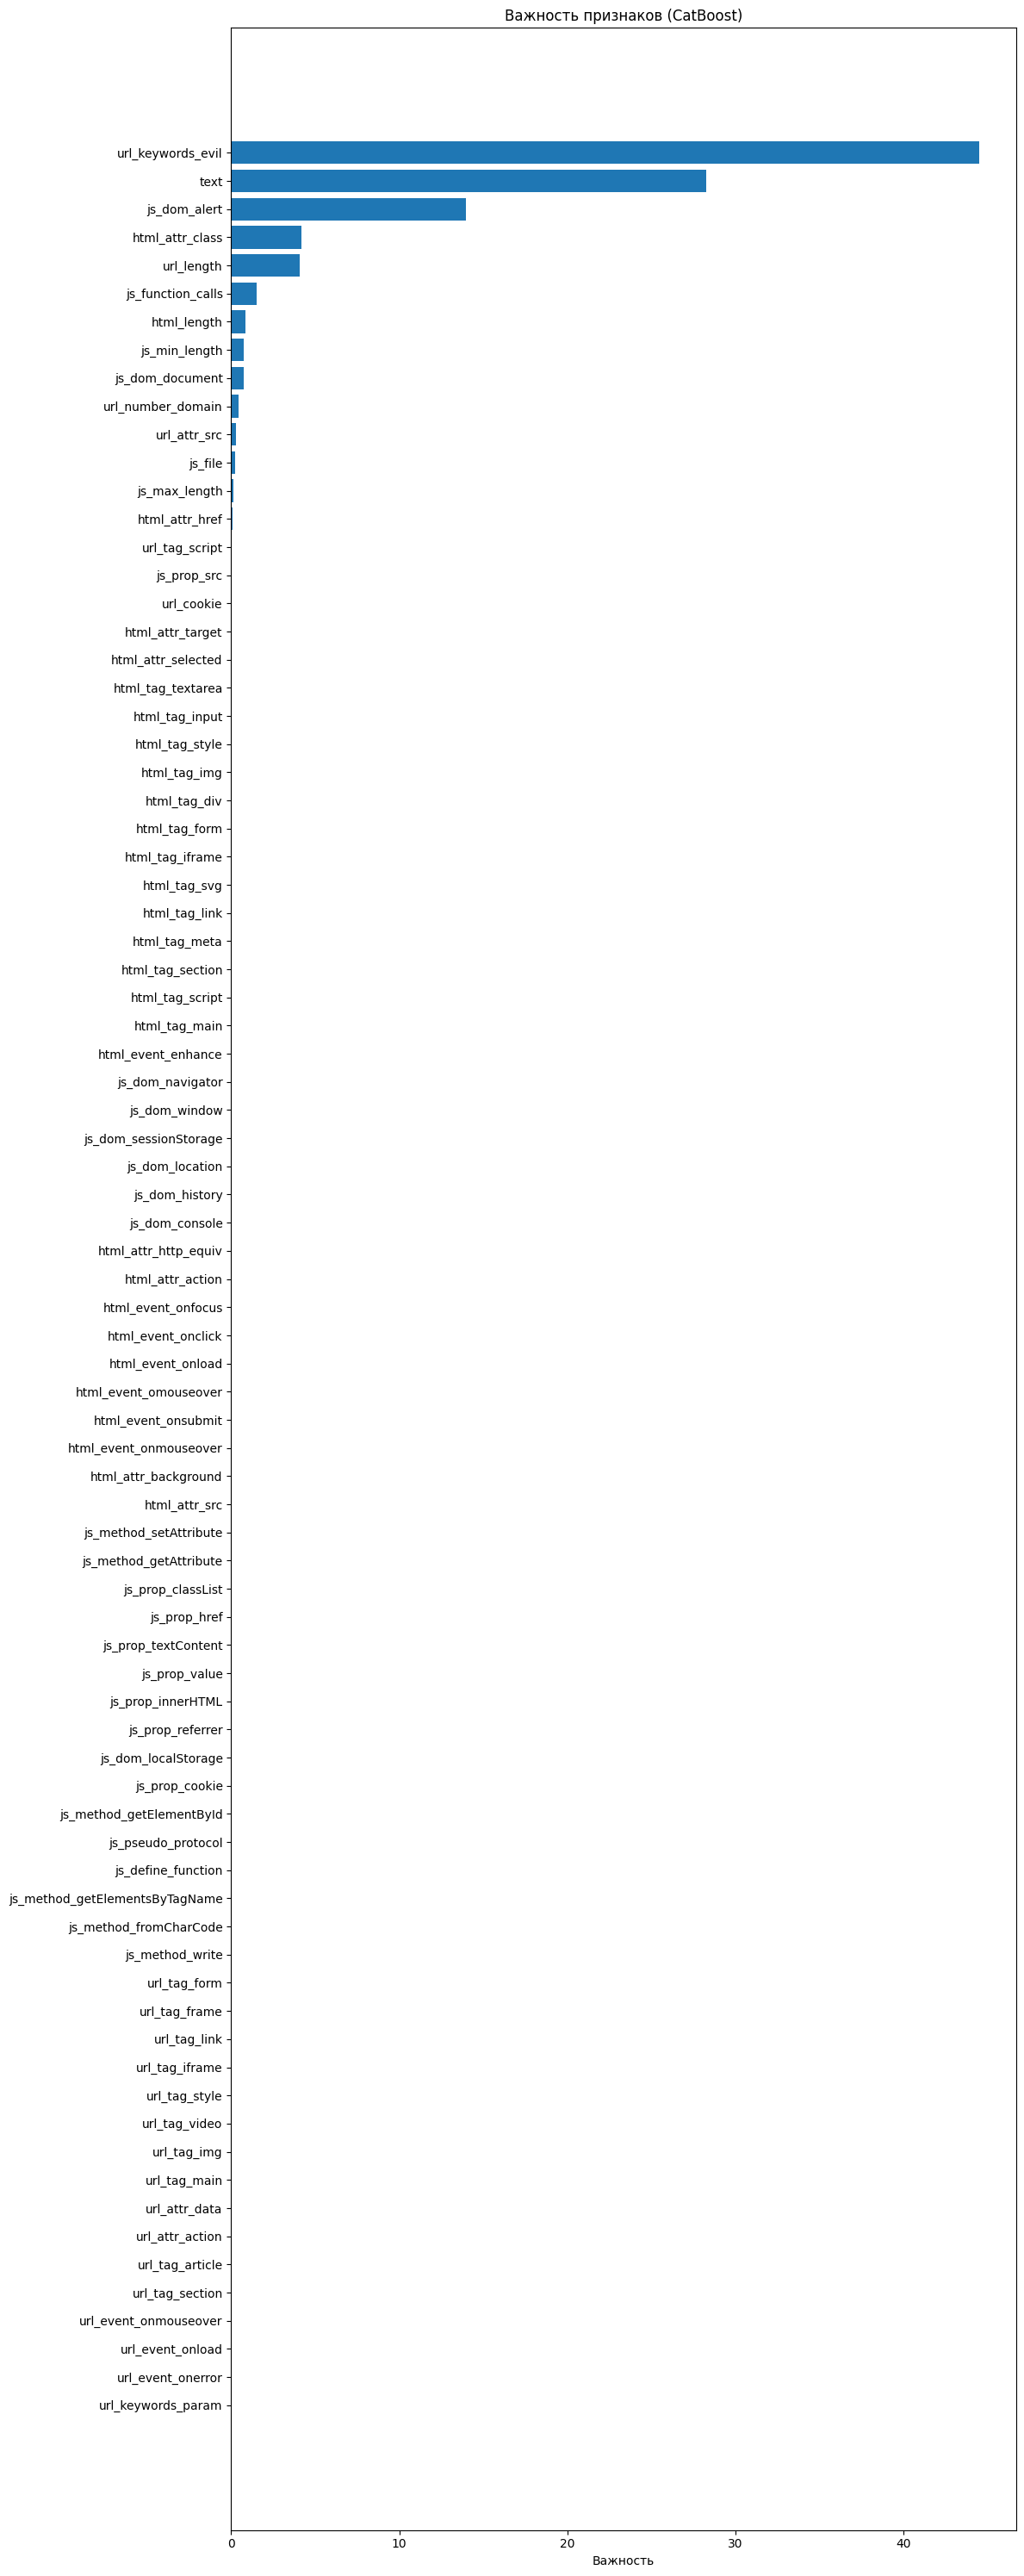

💾 Модель сохранена:
  - ./model/catboost_xss_model.cbm (модель)
  - ./model/model_metadata.pkl (метаданные)


In [9]:
best_params['feature_weights'] = feature_weights
best_params['task_type'] = 'GPU'
# best_params.pop('colsample_bylevel')

model = train_final_model(X, y, cat_features, best_params)

importance_df = analyze_feature_importance(model, X)

model_filename, metadata_filename = learn_detector.save_model(
    model, X.columns, cat_features)

In [10]:
print("\n🧪 Тестирование модели на примерах:")

test_cases = [
    "<script>alert('XSS')</script>",
    "<div>Hello World</div>",
    "<img src=x onerror=alert(1)>",
    "<p>Normal paragraph</p>",
    "<svg onload=alert(document.cookie)>",
    "<a href='/about'>About</a>"
]

metadata = {'feature_names': list(X.columns), 'cat_features': cat_features}

for test in test_cases:
    result = learn_detector.predict_xss(model, test, metadata)
    print(f"\n📝 {result['text']}")
    print(
        f"   XSS: {result['is_xss']} | Вероятность: {result['probability']:.2%} | Риск: {result['risk_level']}")
    if 'triggered_features' in result:
        print(f"   Причины: {', '.join(result['triggered_features'])}")

print("\n" + "=" * 60)
print("✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print("=" * 60)


🧪 Тестирование модели на примерах:

📝 <script>alert('XSS')</script>
   XSS: True | Вероятность: 99.69% | Риск: HIGH
   Причины: 

📝 <div>Hello World</div>
   XSS: False | Вероятность: 22.02% | Риск: LOW

📝 <img src=x onerror=alert(1)>
   XSS: True | Вероятность: 99.84% | Риск: HIGH
   Причины: 

📝 <p>Normal paragraph</p>
   XSS: False | Вероятность: 22.02% | Риск: LOW

📝 <svg onload=alert(document.cookie)>
   XSS: True | Вероятность: 99.82% | Риск: HIGH
   Причины: 

📝 <a href='/about'>About</a>
   XSS: False | Вероятность: 1.84% | Риск: LOW

✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!


In [11]:
# Инициализируем детектор
learn_detector = XSSLearnDetector()
learn_detector.model = model
learn_detector.metadata = metadata

# Тестируем
test_codes = [
    "Normal HTML:_|_<div class='test'>Hello</div>",
    "XSS:_|_<script>alert('hacked')</script>",
    "Tricky:_|_<img src='x' onerror='javascript:alert(1)'>",
    "Encoded:_|_%3Cscript%3Ealert('xss')%3C/script%3E"
]

print("\n🧪 Тестовые предсказания:")
for code in test_codes:
    result = learn_detector.predict_xss(
        model, code.split('_|_')[-1], metadata)
    print(f"\n📝 {result['text']}")
    print(
        f"   XSS: {result['is_xss']} | Вероятность: {result['probability']:.2%} | Риск: {result['risk_level']}")
    if 'triggered_features' in result:
        print(f"   Причины: {', '.join(result['triggered_features'])}")


🧪 Тестовые предсказания:

📝 <div class='test'>Hello</div>
   XSS: False | Вероятность: 4.15% | Риск: LOW

📝 <script>alert('hacked')</script>
   XSS: True | Вероятность: 99.69% | Риск: HIGH
   Причины: 

📝 <img src='x' onerror='javascript:alert(1)'>
   XSS: True | Вероятность: 99.83% | Риск: HIGH
   Причины: 

📝 %3Cscript%3Ealert('xss')%3C/script%3E
   XSS: True | Вероятность: 99.69% | Риск: HIGH
   Причины: 


✅ Модель успешно загружена
   Признаков: 81
   Категориальных: 45

🧪 Тестирование модели...
📊 Загружено 13226 примеров
✅ Confusion matrix сохранена как 'confusion_matrix_xss.png'


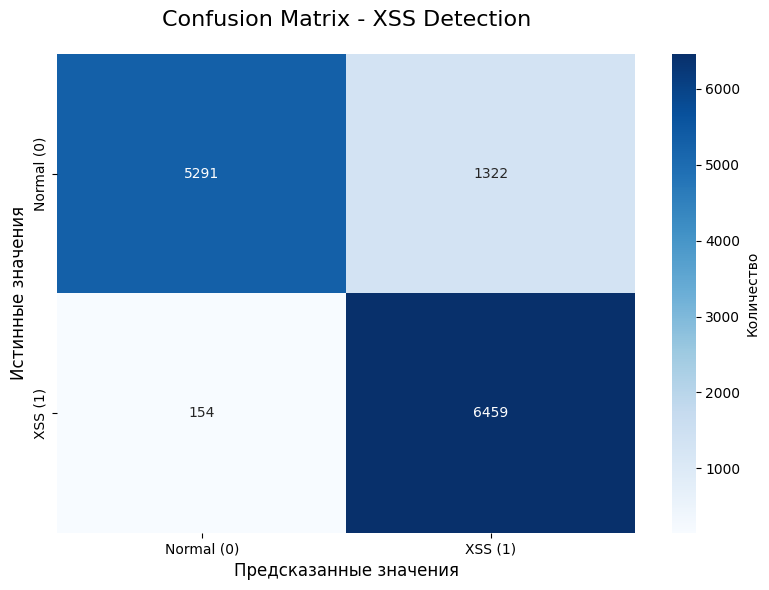


📊 Основные метрики:
True Negatives: 5291
False Positives: 1322
False Negatives: 154
True Positives: 6459
Точность: 88.8%
Precision: 83.01%
Recall: 97.67%
F1-score: 89.75%
FP-rate: 19.99%


In [12]:
test_detector = XSSTestDetector(model_filename, metadata_filename)

print("\n🧪 Тестирование модели...")

# Загрузка данных
df = pd.read_csv(test_filename, encoding='utf-8')
print(f"📊 Загружено {len(df)} примеров")

# Проверяем наличие истинных меток
if 'label' not in df.columns:
    print("❌ Нет истинных меток (label). Не могу построить confusion matrix.")
    exit()

# Прогнозирование
y_true = []
y_pred = []

for i, row in df.iterrows():
    text = row['text']
    true_label = int(row['label'])
    
    result = test_detector.predict(text, threshold=0.35)
    pred_label = int(result['is_xss'])
    
    y_true.append(true_label)
    y_pred.append(pred_label)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar_kws={'label': 'Количество'},
            xticklabels=['Normal (0)', 'XSS (1)'],
            yticklabels=['Normal (0)', 'XSS (1)'])

plt.title('Confusion Matrix - XSS Detection', fontsize=16, pad=20)
plt.ylabel('Истинные значения', fontsize=12)
plt.xlabel('Предсказанные значения', fontsize=12)
plt.tight_layout()

# Сохранение
plt.savefig('confusion_matrix_xss.png', dpi=150, bbox_inches='tight')
print("✅ Confusion matrix сохранена как 'confusion_matrix_xss.png'")

# Показ
plt.show()



# Просто вывод основных чисел
TN, FP, FN, TP = cm.ravel()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
false_positive_rate = FP / (FP + TN) if (FP + TN) > 0 else 0

print(f"\n📊 Основные метрики:")
print(f"True Negatives: {TN}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"True Positives: {TP}")
print(f"Точность: {(TP+TN)/(TP+TN+FP+FN):.1%}")
print("="*50)
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-score: {f1_score:.2%}")
print(f"FP-rate: {false_positive_rate:.2%}")